# 01_eda.ipynb
**Mục tiêu:** Khám phá và đánh giá tập dữ liệu AirBnB Bangkok sau khi xử lý ở tầng Silver, chuẩn bị cho huấn luyện mô hình dự báo giá phòng thuê. Gồm:
- Kiểm tra giá trị thiếu, tính hợp lệ.
- Phân tích phân phối của `price` và các đặc trưng liên quan. 
- Đánh giá mối quan hệ giữa các đặc trưng với `log_price`
- Định hướng xử lý dữ liệu xây dựng mô hình dự báo. 

# Thư viện

In [37]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Dữ liệu

In [38]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import connect_motherduck
from utils.sql import query_dataframe

connection = connect_motherduck(read_only=True)

In [39]:
# Row count
row_counts = query_dataframe(
    connection,
    """
    select 'silver_listings' as dataset, count(*) as rows
    from airbnb_analytics.silver.silver_listings
    union all
    select 'silver_calendar', count(*)
    from airbnb_analytics.silver.silver_calendar
    union all
    select 'silver_reviews', count(*)
    from airbnb_analytics.silver.silver_reviews
    union all
    select 'silver_neighbourhoods', count(*)
    from airbnb_analytics.silver.silver_neighbourhoods
    """
)

row_counts

,dataset,rows
0,silver_listings,28806
1,silver_calendar,10514202
2,silver_reviews,583333
3,silver_neighbourhoods,50


In [104]:
# Dữ liệu listings
listings_eda = query_dataframe(
    connection,
    """
    select
        listing_id,
        -- location
        neighbourhood,
        latitude,
        longitude,

        -- listing attributes
        property_type,
        room_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        -- pricing rules
        price,
        minimum_nights,
        maximum_nights,
        instant_bookable,

        -- host attributes
        host_id,
        host_since,
        host_response_time,
        host_response_rate,
        host_acceptance_rate,
        host_is_superhost,
        host_identity_verified,
        host_listings_count,
        host_total_listings_count,
        calculated_host_listings_count,

        -- availability
        availability_30,
        availability_60,
        availability_90,
        availability_365,

        -- reviews
        number_of_reviews,
        number_of_reviews_ltm,
        last_review,
        reviews_per_month,

        -- review scores
        review_scores_rating,
        review_scores_accuracy,
        review_scores_cleanliness,
        review_scores_checkin,
        review_scores_communication,
        review_scores_location,
        review_scores_value

    from airbnb_analytics.silver.silver_listings
    order by listing_id
    """
)

listings_eda.head()

,listing_id,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_ltm,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,27934,Ratchathewi,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.0,1.0,...,0,2024-09-17,0.40,4.86,4.95,4.82,4.97,4.91,4.66,4.75
1,27979,Bang Na,13.66818,100.61674,Private room in rental unit,Private room,2,1.0,NaN,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28745,Bang Kapi,13.75232,100.62402,Private room in rental unit,Private room,2,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,47516,Don Mueang,13.92726,100.58529,Entire home,Entire home/apt,1,NaN,4.0,1.0,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,48736,Rat Burana,13.68556,100.49535,Private room in rental unit,Private room,2,1.0,1.0,1.0,...,0,2014-02-03,0.01,5.00,5.00,5.00,5.00,5.00,5.00,5.00


# EDA

In [105]:
# Tổng quan về dữ liệu
listings_eda.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
listing_id,28806.0,799504135292119296.0,578611715967888128.0,27934.0,40217193.5,994658278891122688.0,1314730451711460864.0,1518168294097881344.0
latitude,28806.0,13.744811,0.040952,13.52937,13.720365,13.73955,13.758728,13.95354
longitude,28806.0,100.562735,0.049999,100.328924,100.53098,100.56604,100.585742,100.92371
accommodates,28806.0,3.137541,2.275833,1.0,2.0,2.0,4.0,16.0
bathrooms,28655.0,1.390578,1.191579,0.0,1.0,1.0,1.0,50.0
bedrooms,27502.0,1.41797,1.406303,0.0,1.0,1.0,1.0,50.0
beds,23224.0,1.820961,1.835147,0.0,1.0,1.0,2.0,50.0
price,23273.0,2528.749151,16473.896035,4.0,923.0,1379.0,2207.0,1000000.0
minimum_nights,28806.0,14.107373,43.243299,1.0,1.0,2.0,14.0,1115.0
maximum_nights,28806.0,489.5243,897.307655,1.0,365.0,365.0,365.0,100000.0


In [106]:
# Check missing values
missing = listings_eda.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

review_scores_value            35.048254
review_scores_location         35.041311
review_scores_checkin          35.037839
review_scores_cleanliness      35.030896
review_scores_communication    35.030896
reviews_per_month              35.027425
last_review                    35.027425
review_scores_rating           35.027425
review_scores_accuracy         35.027425
host_response_rate             19.603555
beds                           19.377907
price                          19.207804
host_acceptance_rate           14.854544
host_is_superhost               5.589113
bedrooms                        4.526835
bathrooms                       0.524196
host_response_time              0.031243
host_identity_verified          0.031243
host_listings_count             0.031243
host_total_listings_count       0.031243
host_since                      0.031243
dtype: float64

**Nhận xét:** 
- Nhóm review missing khoảng 35% hoặc Nhóm Host response khoảng 15 - 20% do nguyên nhân nghiệp vụ. 
- Nhóm Price 19% bất thường, tuy nhiên vẫn đủ để huấn luyện mô hình. Thực hiện loại bỏ các dòng null. 

In [107]:
listings_eda[
    listings_eda["price"].isna()
].head()

,listing_id,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_ltm,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
1,27979,Bang Na,13.66818,100.61674,Private room in rental unit,Private room,2,1.0,NaN,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28745,Bang Kapi,13.75232,100.62402,Private room in rental unit,Private room,2,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,62217,Phaya Thai,13.79152,100.53982,Private room in home,Private room,2,1.0,NaN,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,159355,Yan na wa,13.71363,100.54652,Entire condo,Entire home/apt,2,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,169285,Huai Khwang,13.78118,100.58349,Private room in rental unit,Private room,3,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
# Kiểm tra số dòng trước khi loại
print("Before:", listings_eda.shape)

# Loại các dòng thiếu target price
listings_v2 = listings_eda.dropna(subset=["price"]).copy()

# Kiểm tra sau khi loại
print("After:", listings_v2.shape)

# Kiểm tra còn missing price không
print("Missing price:", listings_v2["price"].isna().sum())

Before: (28806, 39)
After: (23273, 39)
Missing price: 0


## Biến target: Price

In [109]:
listings_v2["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count      23273.000000
mean        2528.749151
std        16473.896035
min            4.000000
1%           340.720000
5%           549.000000
25%          923.000000
50%         1379.000000
75%         2207.000000
95%         6000.000000
99%        16669.600000
max      1000000.000000
Name: price, dtype: float64

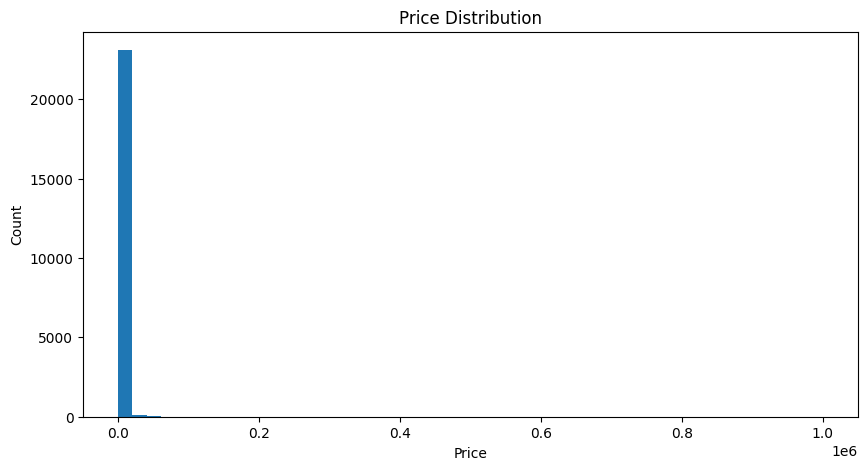

In [110]:
plt.figure(figsize=(10, 5))
plt.hist(listings_v2["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

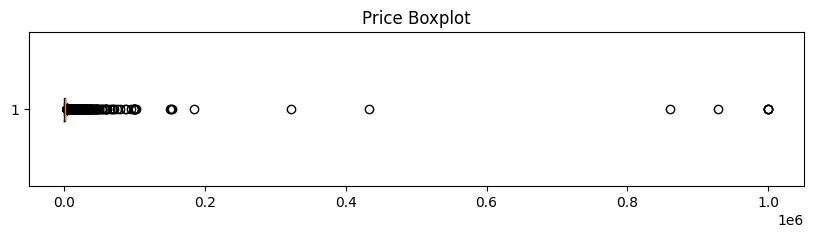

In [111]:
plt.figure(figsize=(10, 2))

plt.boxplot(
    listings_v2["price"].dropna(),
    vert=False
)

plt.title("Price Boxplot")
plt.show()

Nhận xét về biến target `price`:
- Phân phối lệch phải mạnh
- Khoảng giá từ 923 - 2.207 THB
- Cân nhắc biến đổi log để giảm ảnh hưởng của outlier lên mô hình

In [112]:
listings_v2["log_price"] = np.log1p(listings_v2["price"])

<Axes: >

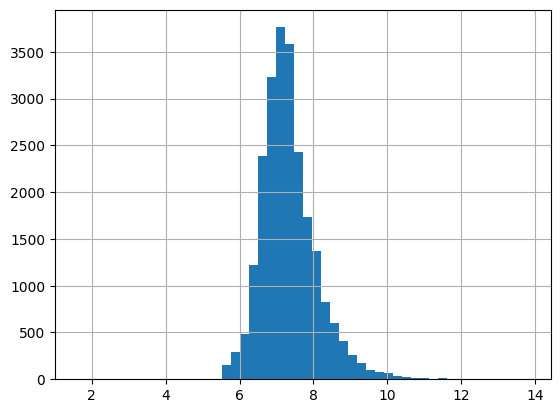

In [113]:
listings_v2["log_price"].hist(bins=50)

## Tổng quan về chất lượng dữ liệu

In [114]:
# Check missing values
missing = listings_v2.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

review_scores_value            30.765264
review_scores_checkin          30.760968
review_scores_communication    30.760968
review_scores_location         30.760968
last_review                    30.756671
reviews_per_month              30.756671
review_scores_accuracy         30.756671
review_scores_cleanliness      30.756671
review_scores_rating           30.756671
host_response_rate             11.842049
host_acceptance_rate            7.399132
host_is_superhost               6.333520
bedrooms                        0.378121
bathrooms                       0.257809
beds                            0.227732
host_since                      0.030078
host_identity_verified          0.030078
host_total_listings_count       0.030078
host_listings_count             0.030078
host_response_time              0.030078
dtype: float64

### Nhóm review ~ 30.76%

In [115]:
(
    listings_v2["number_of_reviews"] == 0
).mean()

np.float64(0.30756670820263826)

**Nhận xét:**
- Khoảng 30,76% listing không có thông tin đánh giá, tần suất và thời gian đánh giá gần nhất. Sau khi kiểm tra biến 
`number_of_reviews` cho thấy tỷ lệ listing chưa từng nhận đánh giá đúng bằng 30,76%. Điều này cho thấy giá trị thiếu phản ánh trạng thái nghiệp vụ.
- Thực hiện fill 0.

In [116]:
# Fill 0 cho giá trị thiếu nhóm review
review_columns = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

listings_v2[review_columns] = (
    listings_v2[review_columns]
    .fillna(0)
)

listings_v2["reviews_per_month"] = (
    listings_v2["reviews_per_month"]
    .fillna(0)
)

### Nhóm host ~ 0 - 11%

In [117]:
# Chiếm  ~ 0% nên loại bỏ để làm sạch dữ liệu
listings_v2 = listings_v2.dropna(
    subset=[
        "host_since",
        "host_total_listings_count",
        "host_identity_verified",
        "host_listings_count",
        "host_response_time"
    ]
)

In [118]:
# Fill median cho 7 - 11%
listings_v2["host_response_rate"] = (
    listings_v2["host_response_rate"]
    .fillna(listings_v2["host_response_rate"].median())
)

listings_v2["host_acceptance_rate"] = (
    listings_v2["host_acceptance_rate"]
    .fillna(listings_v2["host_acceptance_rate"].median())
)

In [119]:
# Fill f nếu thiếu host_is_superhost
# Fill missing bằng False
listings_v2["host_is_superhost"] = (
    listings_v2["host_is_superhost"]
    .fillna(False)
    .astype(int)
)

### Nhóm bedrooms, bathrooms, beds

In [120]:
# Thực hiện fill median theo nhóm room_type để giữ được sự khác biệt giữa các loại phòng
for col in ["bedrooms", "bathrooms", "beds"]:
    listings_v2[col] = listings_v2[col].fillna(
        listings_v2.groupby("room_type")[col]
        .transform("median")
    )

## Phân tích biến đặc trưng với biến target

### Nhóm đặc điểm phòng

In [121]:
# Phân bố các biến số lượng phòng và loại phòng
room_features_num = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds"
]

room_features_cat = [
    "room_type",
    "property_type"
]
display(listings_v2[room_features_num].describe(include="number").T)
display(listings_v2[room_features_cat].describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
accommodates,23266.0,3.216926,2.359248,1.0,2.0,2.0,4.0,16.0
bedrooms,23266.0,1.393321,1.159636,0.0,1.0,1.0,1.0,50.0
bathrooms,23266.0,1.397640,1.044568,0.0,1.0,1.0,1.5,50.0
beds,23266.0,1.819350,1.833843,0.0,1.0,1.0,2.0,50.0


,count,unique,top,freq
room_type,23266,4,Entire home/apt,16495
property_type,23266,73,Entire rental unit,10332


In [122]:
for col in ["bedrooms", "bathrooms", "beds"]:
    print(col)
    print(
        listings_v2[col].describe(
            percentiles=[0.95,0.99]
        )
    )

bedrooms
count    23266.000000
mean         1.393321
std          1.159636
min          0.000000
95%          3.000000
99%          6.000000
max         50.000000
Name: bedrooms, dtype: float64
bathrooms
count    23266.000000
mean         1.397640
std          1.044568
min          0.000000
95%          3.000000
99%          6.000000
max         50.000000
Name: bathrooms, dtype: float64
beds
count    23266.000000
mean         1.819350
std          1.833843
min          0.000000
95%          5.000000
99%          9.000000
max         50.000000
Name: beds, dtype: float64


**Nhận xét:**
- Các biến `bedrooms`, `bathrooms`, `beds` có phân phối lệch phải, phần lớn listing là các căn nhỏ, med ~ 1 bed, 1 bathroom, 1 bedroom. 
- Tồn tại một số giá trị cực lớn 50 bedrooms, 50 bathrooms, 50 beds. Các trường hợp này chiếm tỷ lệ nhỏ (đa phần của villa lớn, townhouse, khách sạn)
- Quyết định giữ nguyên để đảm bảo đặc điểm của dữ liệu. 

In [123]:
# Median log_price theo room_type
listings_v2.groupby("room_type")["log_price"].agg(
    count="count",
    mean="mean",
    median="median"
).sort_values("median", ascending=False)

,count,mean,median
room_type,,,
Hotel room,198,7.375573,7.443944
Entire home/apt,16495,7.436459,7.313887
Private room,6259,7.100007,6.993933
Shared room,314,6.092027,5.888878


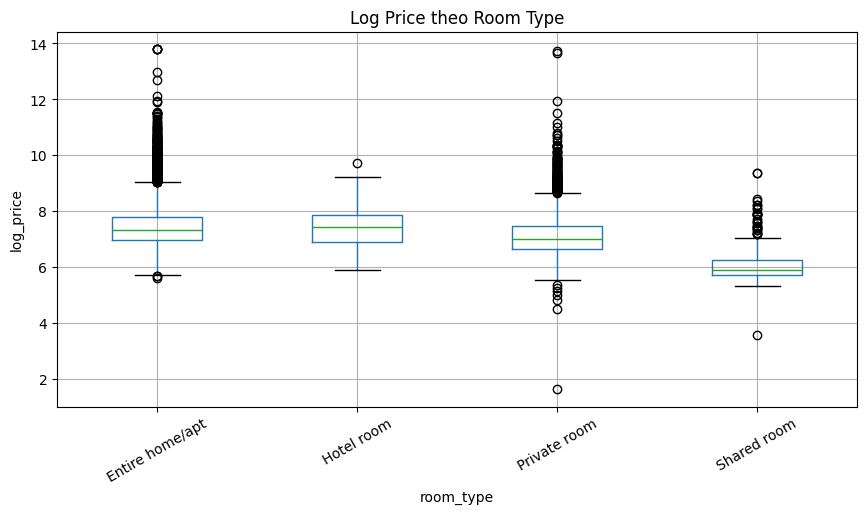

In [124]:
listings_v2.boxplot(
    column="log_price",
    by="room_type",
    figsize=(10, 5)
)

plt.title("Log Price theo Room Type")
plt.suptitle("")
plt.xlabel("room_type")
plt.ylabel("log_price")
plt.xticks(rotation=30)
plt.show()

In [125]:
# Median log_price theo property_type
property_summary = listings_v2.groupby("property_type")["log_price"].agg(
    count="count",
    mean="mean",
    median="median"
).sort_values("median", ascending=False)
property_summary.head(5)

,count,mean,median
property_type,,,
Private room in farm stay,1,9.105091,9.105091
Entire villa,88,9.115980,9.035808
Lighthouse,2,8.298331,8.298331
Farm stay,1,8.207947,8.207947
Entire home,1268,8.243568,8.176813


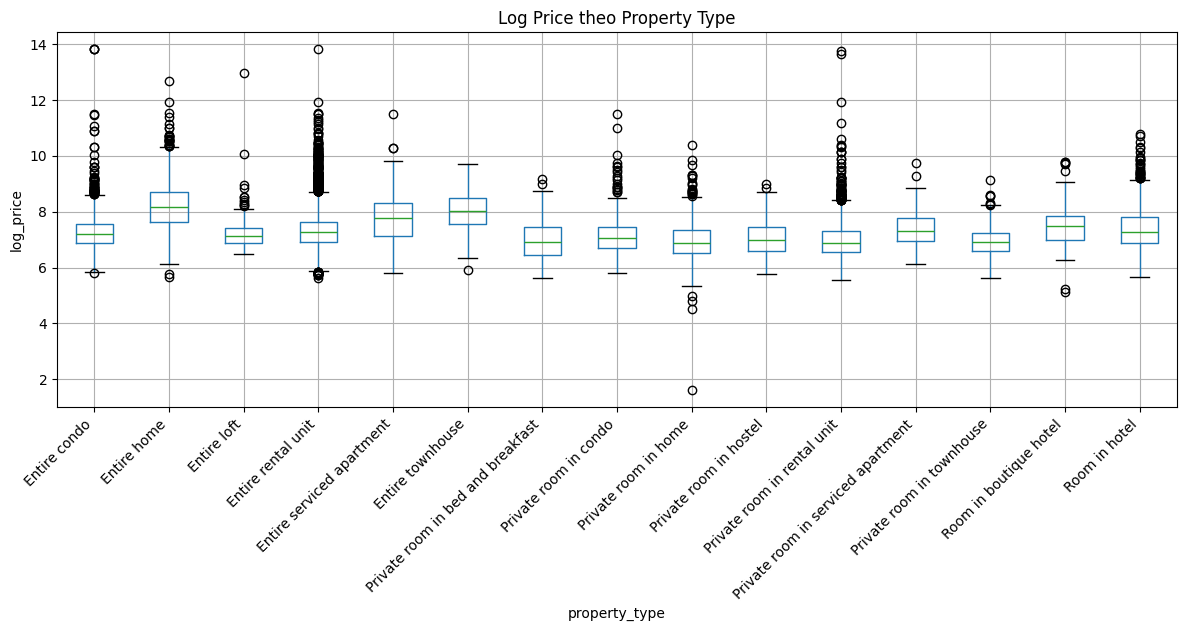

In [126]:
top_property_types = (
    listings_v2["property_type"]
    .value_counts()
    .head(15)
    .index
)

data_top_property = listings_v2[
    listings_v2["property_type"].isin(top_property_types)
]

data_top_property.boxplot(
    column="log_price",
    by="property_type",
    figsize=(14, 5)
)

plt.title("Log Price theo Property Type")
plt.suptitle("")
plt.xlabel("property_type")
plt.ylabel("log_price")
plt.xticks(rotation=45, ha="right")
plt.show()

**Nhận xét:** 
- `room_type` ảnh hưởng mạnh tới giá, các listings Entire home/apt hoặc hotel thường có mức giá cao hơn đáng kể so với private_room, shared room.
- `property_type` có sự khác nhau đáng kể về giá thuê giữa các nhóm. Trong từng nhóm có độ phân tán lớn. 

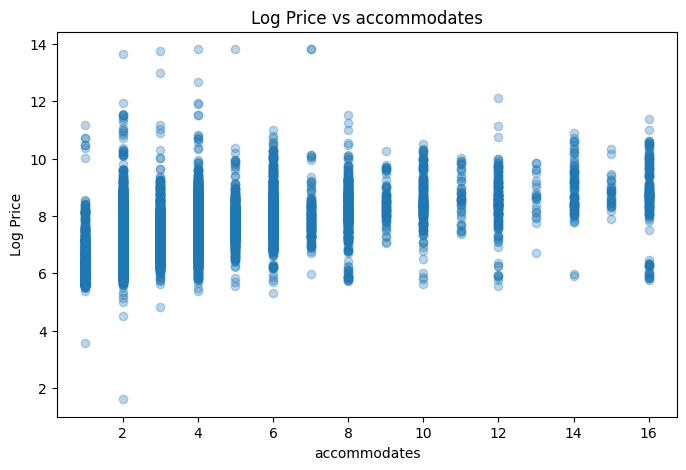

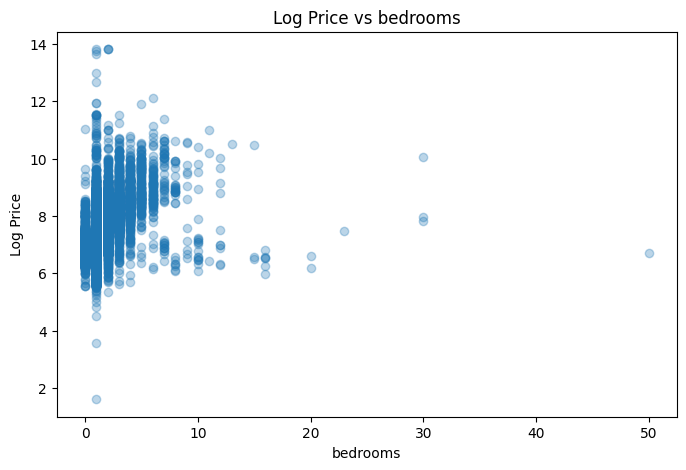

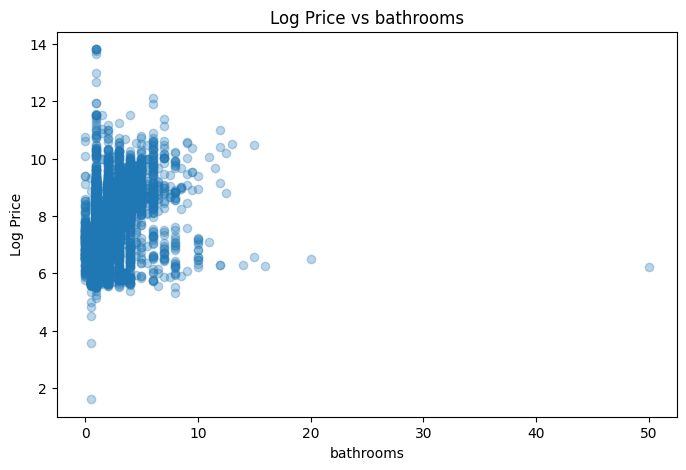

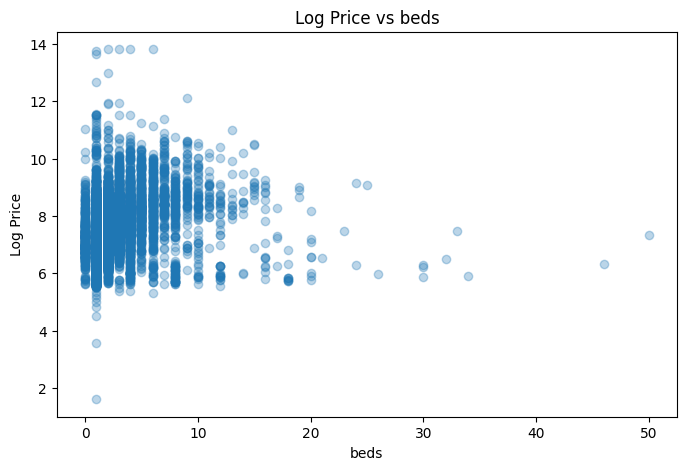

In [127]:
# Biến numberic với log_price
for col in room_features_num:
    plt.figure(figsize=(8, 5))
    plt.scatter(
        listings_v2[col],
        listings_v2["log_price"],
        alpha=0.3
    )
    plt.title(f"Log Price vs {col}")
    plt.xlabel(col)
    plt.ylabel("Log Price")
    plt.show()

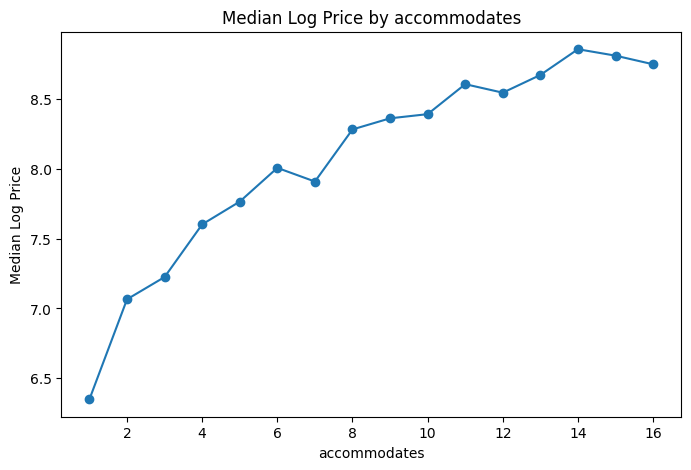

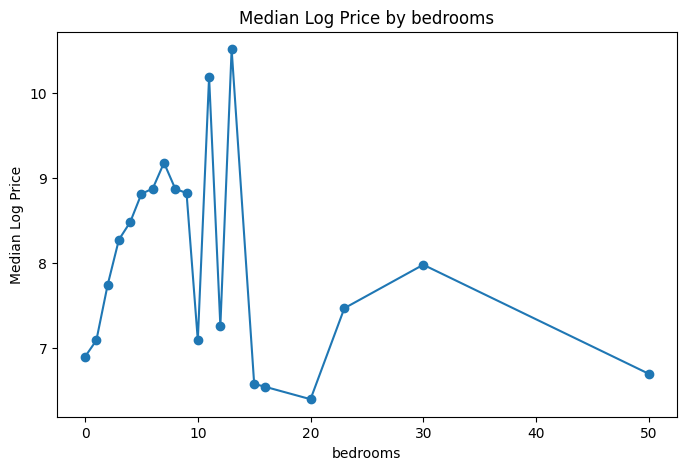

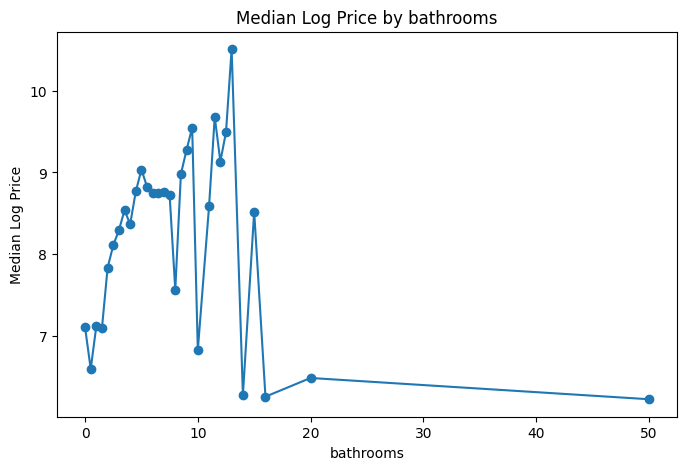

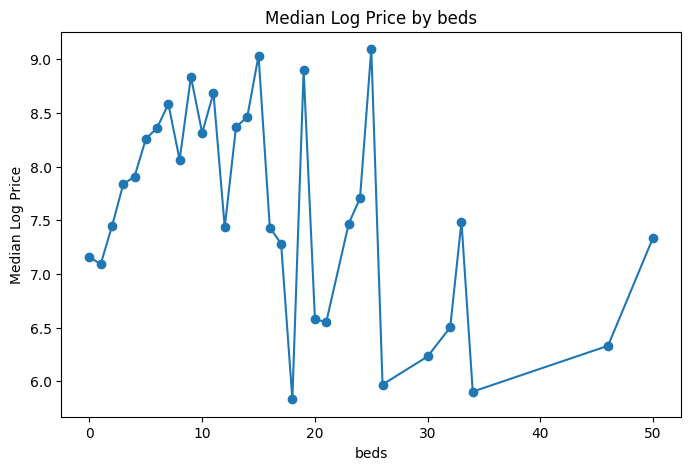

In [128]:
# Median log_price theo các biến số lượng phòng
for col in room_features_num:
    summary = listings_v2.groupby(col)["log_price"].agg(
        count="count",
        mean="mean",
        median="median"
    ).reset_index()
    plt.figure(figsize=(8, 5))
    plt.plot(summary[col], summary["median"], marker="o")
    plt.title(f"Median Log Price by {col}")
    plt.xlabel(col)
    plt.ylabel("Median Log Price")
    plt.show()

**Nhận xét:**
- `accommondates`:
    + Có xu hướng dương: sức chứa càng lớn, giá càng cao.
    + Mỗi mức accommondates vẫn có độ phân tán lớn. 
    + Sau khoảng 12 - 16, đường cong bắt đầu phẳng. Cho thấy, giá tăng theo sức chưa nhưng không tăng tuyến tính mãi. 
- `bedrooms`, `bathrooms`, `beds`: 
    + Có mối quan hệ thuận chiều với giá.
    + Một số giá trị lớn xuất hiện với tần suất thấp. 

In [129]:
# Tương quan trong nhóm
room_corr = listings_v2[
    room_features_num + ["log_price"]
].corr()

room_corr

,accommodates,bedrooms,bathrooms,beds,log_price
accommodates,1.000000,0.668247,0.642219,0.738087,0.529955
bedrooms,0.668247,1.000000,0.621429,0.602710,0.449482
bathrooms,0.642219,0.621429,1.000000,0.575144,0.396788
beds,0.738087,0.602710,0.575144,1.000000,0.326858
log_price,0.529955,0.449482,0.396788,0.326858,1.000000


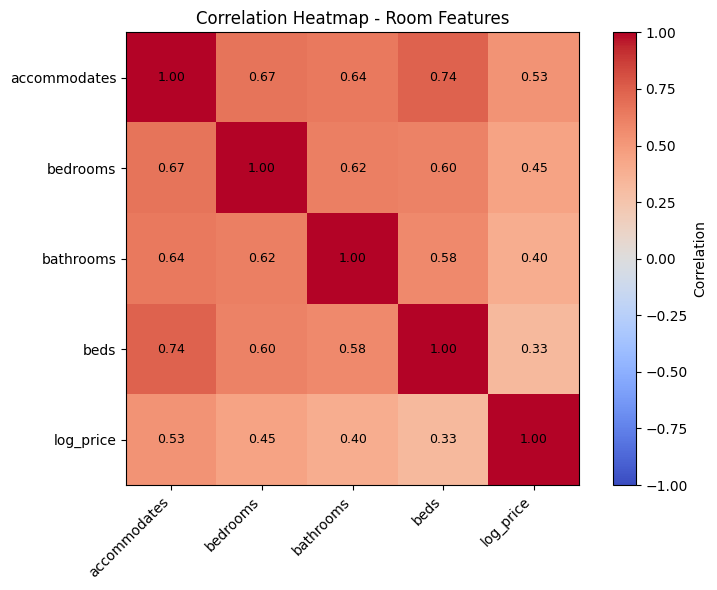

In [130]:
plt.figure(figsize=(8, 6))

plt.imshow(
    room_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(room_corr.columns)),
    room_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(room_corr.columns)),
    room_corr.columns
)

for i in range(len(room_corr)):
    for j in range(len(room_corr)):
        plt.text(
            j,
            i,
            f"{room_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Heatmap - Room Features")
plt.tight_layout()
plt.show()

**Nhận xét:**
- `accommondates` có tương quan cao với `log_price`, yếu tố quan trọng. 
- `bedrooms`, `bathrooms`, `beds` tương quan dương, nhưng đồng thời cũng có tương quan khá cao với nhau. Nên đánh giá lại bằng feature importance.

### Nhóm vị trí

In [131]:
location_features = [
    "neighbourhood",
    "latitude",
    "longitude"
]

In [132]:
# Số lượng listing theo neighbourhood
neighbourhood_count = (
    listings_v2["neighbourhood"]
    .value_counts()
    .reset_index()
)

neighbourhood_count.columns = ["neighbourhood", "count"]

neighbourhood_count.head(20)

,neighbourhood,count
0,Vadhana,3705
1,Khlong Toei,3119
2,Huai Khwang,3033
3,Ratchathewi,1243
4,Sathon,1092
5,Phra Khanong,1001
6,Phra Nakhon,923
7,Bang Rak,756
8,Suanluang,728
9,Chatu Chak,681


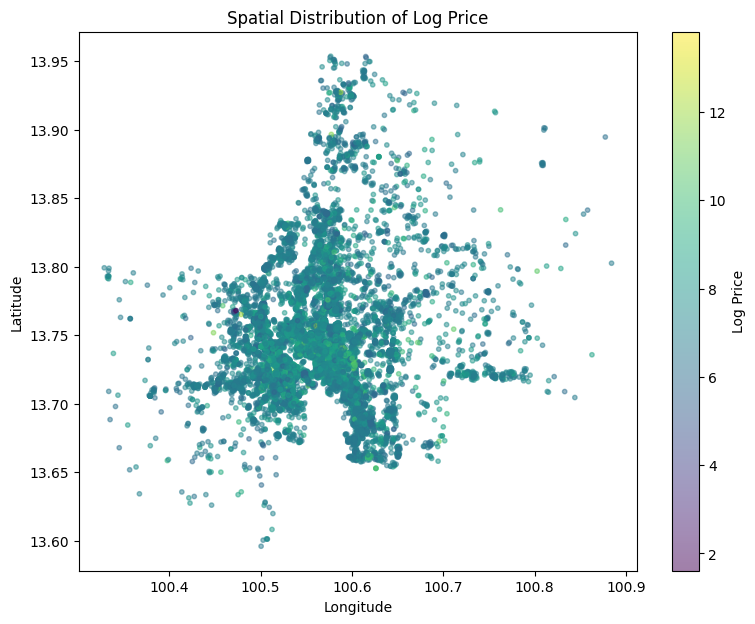

In [133]:
# Scatter vị trí theo log_price
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    listings_v2["longitude"],
    listings_v2["latitude"],
    c=listings_v2["log_price"],
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label="Log Price")
plt.title("Spatial Distribution of Log Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Nhận xét:**
- Phân bố theo khu vực không đồng đều. 
- Một số khu vực: Vadhana, Khlong Toei, Huai Khwang chiếm số lượng vượt trội.
- Sử dụng `neighbourhood` thay vì `lattitude` và `longtitude`.

### Nhóm availability

In [134]:
# Tỷ lệ ngày trống
availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

availability_days = {
    "availability_30": 30,
    "availability_60": 60,
    "availability_90": 90,
    "availability_365": 365
}

for col, days in availability_days.items():
    listings_eda[f"{col}_rate"] = listings_eda[col] / days

availability_rate_cols = [
    "availability_30_rate",
    "availability_60_rate",
    "availability_90_rate",
    "availability_365_rate"
]

In [135]:
# Phân phối tỷ lệ ngày trống
availability_describe = (
    listings_eda[availability_rate_cols]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9])
    .T
    .round(3)
)

display(availability_describe)

,count,mean,std,min,25%,50%,75%,90%,max
availability_30_rate,28806.0,0.631,0.396,0.0,0.233,0.833,0.967,1.0,1.0
availability_60_rate,28806.0,0.674,0.378,0.0,0.400,0.883,0.983,1.0,1.0
availability_90_rate,28806.0,0.696,0.369,0.0,0.444,0.911,0.989,1.0,1.0
availability_365_rate,28806.0,0.685,0.346,0.0,0.460,0.795,0.995,1.0,1.0


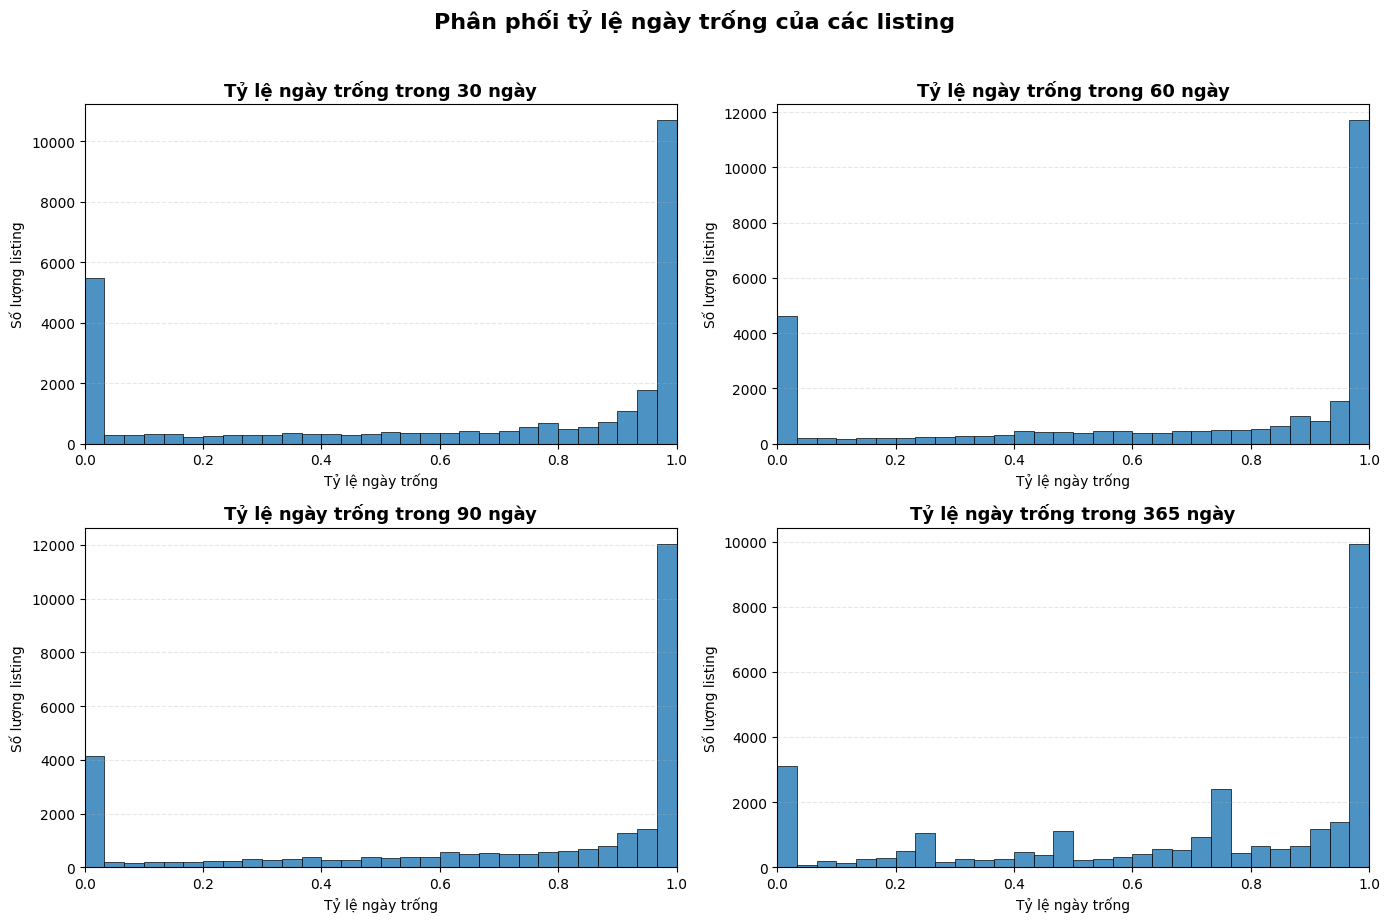

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

titles = {
    "availability_30_rate": "Tỷ lệ ngày trống trong 30 ngày",
    "availability_60_rate": "Tỷ lệ ngày trống trong 60 ngày",
    "availability_90_rate": "Tỷ lệ ngày trống trong 90 ngày",
    "availability_365_rate": "Tỷ lệ ngày trống trong 365 ngày"
}

for ax, col in zip(axes.flat, availability_rate_cols):
    data = listings_eda[col].dropna()

    ax.hist(
        data,
        bins=30,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8
    )

    ax.set_title(titles[col], fontsize=13, fontweight="bold")
    ax.set_xlabel("Tỷ lệ ngày trống")
    ax.set_ylabel("Số lượng listing")
    ax.set_xlim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Phân phối tỷ lệ ngày trống của các listing",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

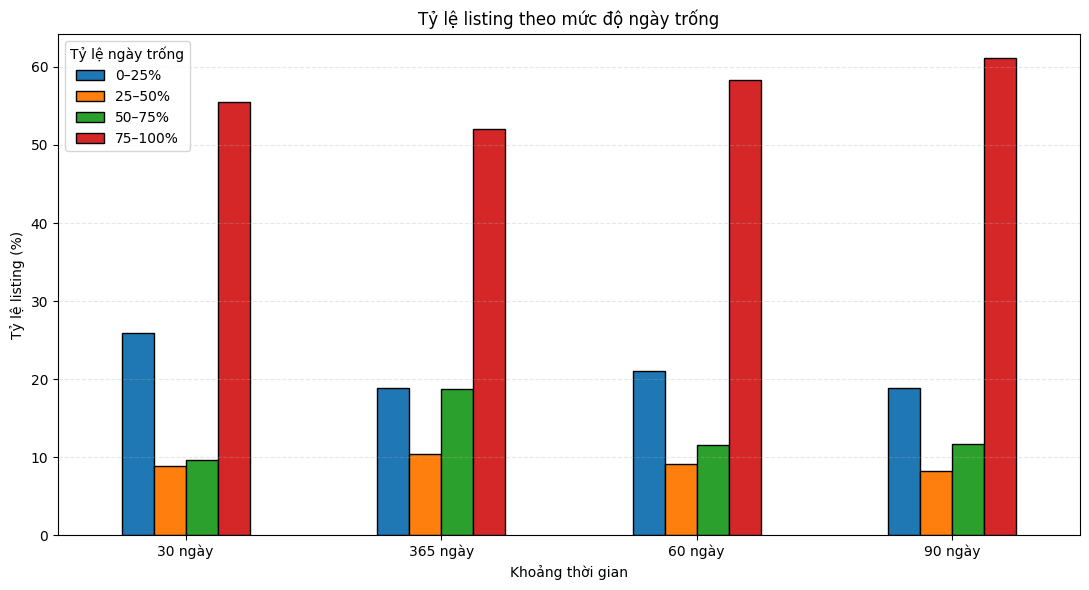

In [137]:
availability_grouped = []

bins = [-0.01, 0.25, 0.50, 0.75, 1.00]
labels = ["0–25%", "25–50%", "50–75%", "75–100%"]

for col in availability_rate_cols:
    groups = pd.cut(
        listings_eda[col],
        bins=bins,
        labels=labels
    )

    counts = groups.value_counts(normalize=True).sort_index() * 100

    for group, value in counts.items():
        availability_grouped.append({
            "period": titles[col].replace("Tỷ lệ ngày trống trong ", ""),
            "group": group,
            "percentage": value
        })

availability_grouped = pd.DataFrame(availability_grouped)

pivot_availability = availability_grouped.pivot(
    index="period",
    columns="group",
    values="percentage"
)

pivot_availability.plot(
    kind="bar",
    figsize=(11, 6),
    edgecolor="black"
)

plt.title("Tỷ lệ listing theo mức độ ngày trống")
plt.xlabel("Khoảng thời gian")
plt.ylabel("Tỷ lệ listing (%)")
plt.xticks(rotation=0)
plt.legend(title="Tỷ lệ ngày trống")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Phân phối không chuẩn, dạng 2 cực
- `availability_365` xuất hiện các đỉnh quanh 25%, 50%, 75%. 
- Tuy nhiên, availability thấp có thể phản ánh lịch đã được đặt hoặc ngày bị khoá, nên không thể phản ánh như tỷ lệ lấp đầy thực tế. 

### Nhóm review

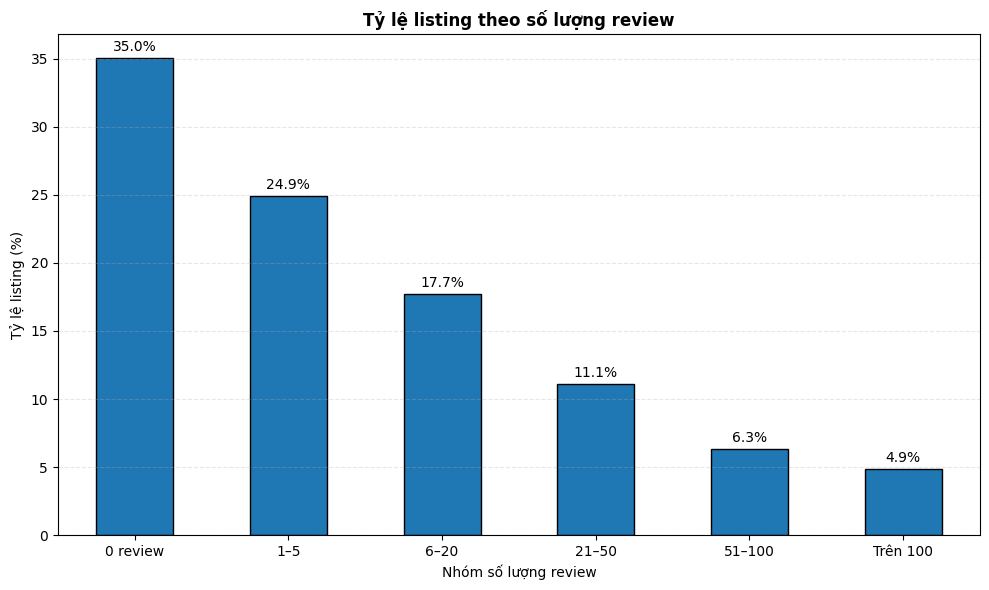

In [138]:
review_count_bins = [-1, 0, 5, 20, 50, 100, np.inf]

review_count_labels = [
    "0 review",
    "1–5",
    "6–20",
    "21–50",
    "51–100",
    "Trên 100"
]

listings_eda["review_count_group"] = pd.cut(
    listings_eda["number_of_reviews"],
    bins=review_count_bins,
    labels=review_count_labels
)

review_count_share = (
    listings_eda["review_count_group"]
    .value_counts(normalize=True)
    .reindex(review_count_labels)
    .mul(100)
)

ax = review_count_share.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

ax.set_title("Tỷ lệ listing theo số lượng review", fontweight="bold")
ax.set_xlabel("Nhóm số lượng review")
ax.set_ylabel("Tỷ lệ listing (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

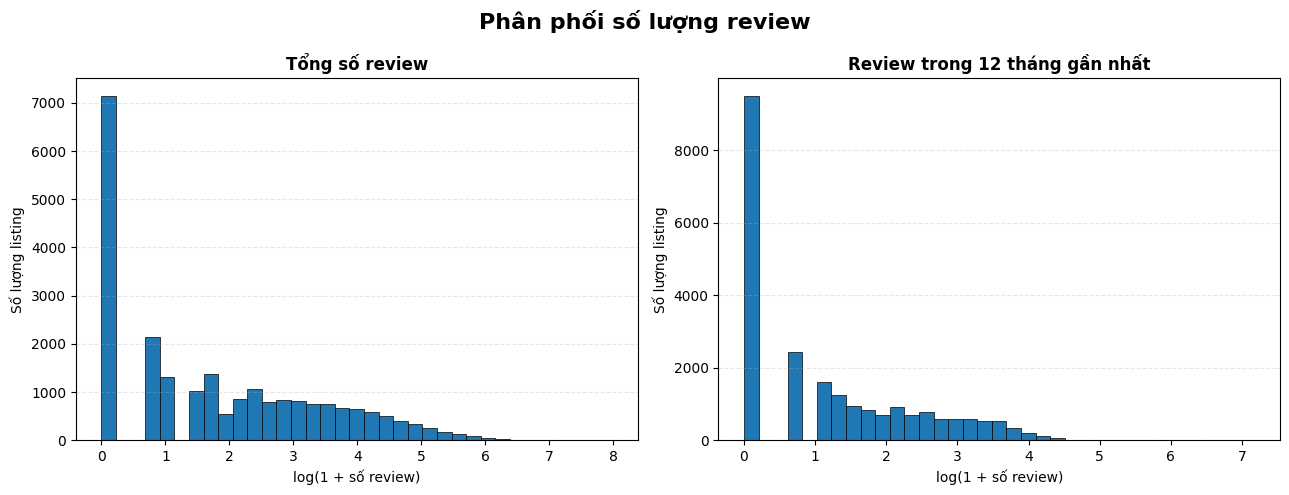

In [141]:
review_activity_cols = [
    "number_of_reviews",
    "number_of_reviews_ltm"
]

titles = {
    "number_of_reviews": "Tổng số review",
    "number_of_reviews_ltm": "Review trong 12 tháng gần nhất"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, review_activity_cols):
    data = np.log1p(listings_v2[col].dropna())

    ax.hist(
        data,
        bins=35,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(titles[col], fontweight="bold")
    ax.set_xlabel("log(1 + số review)")
    ax.set_ylabel("Số lượng listing")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Phân phối số lượng review",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

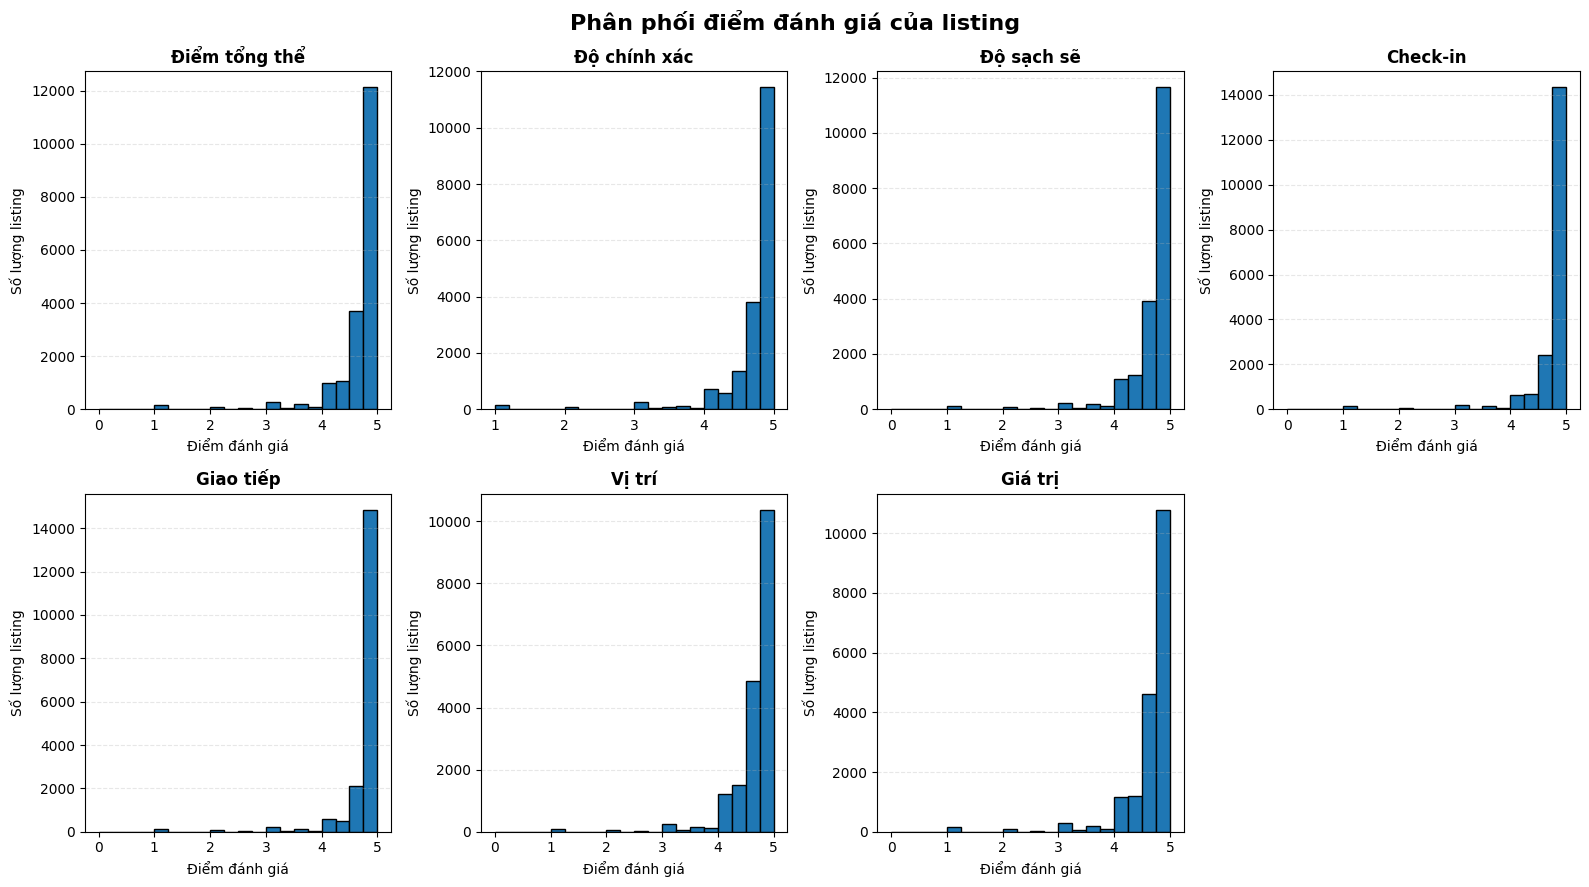

In [142]:
# Phân phối các điểm đánh giá
review_score_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

review_score_cols = [
    col for col in review_score_cols
    if col in listings_eda.columns
]

score_titles = {
    "review_scores_rating": "Điểm tổng thể",
    "review_scores_accuracy": "Độ chính xác",
    "review_scores_cleanliness": "Độ sạch sẽ",
    "review_scores_checkin": "Check-in",
    "review_scores_communication": "Giao tiếp",
    "review_scores_location": "Vị trí",
    "review_scores_value": "Giá trị"
}

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, review_score_cols):
    listings_eda[col].dropna().plot(
        kind="hist",
        bins=20,
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(score_titles[col], fontweight="bold")
    ax.set_xlabel("Điểm đánh giá")
    ax.set_ylabel("Số lượng listing")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

for ax in axes[len(review_score_cols):]:
    ax.set_visible(False)

plt.suptitle(
    "Phân phối điểm đánh giá của listing",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

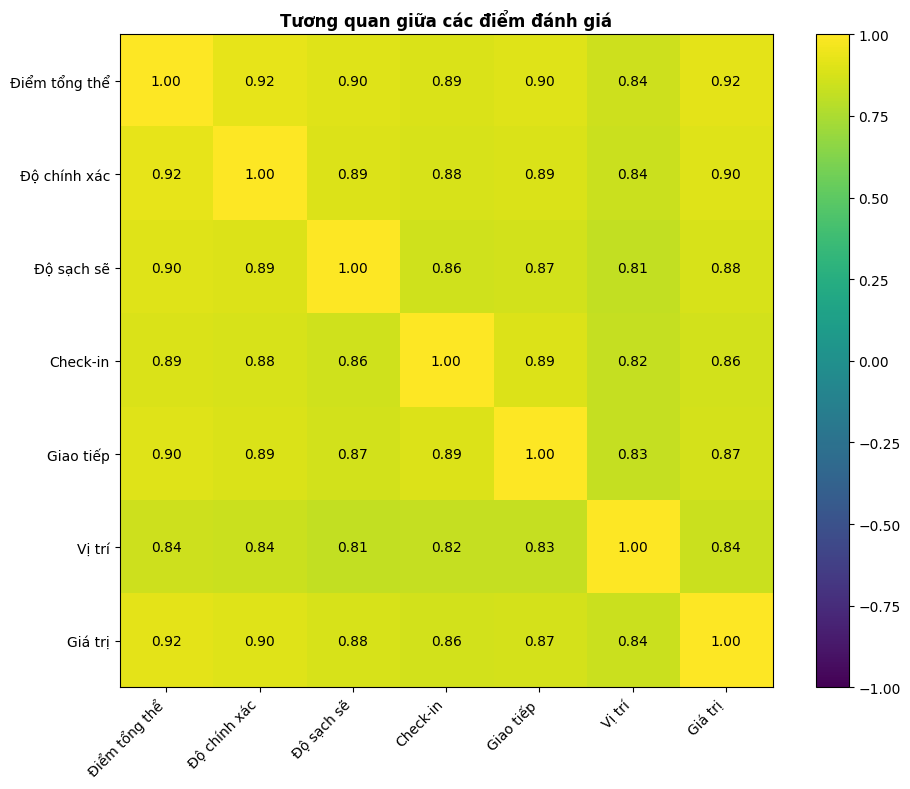

In [143]:
# Tương quan giữa các điểm review
review_score_corr = listings_v2[
    review_score_cols
].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    review_score_corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(review_score_cols)))
ax.set_yticks(range(len(review_score_cols)))

ax.set_xticklabels(
    [score_titles[col] for col in review_score_cols],
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    [score_titles[col] for col in review_score_cols]
)

for i in range(len(review_score_cols)):
    for j in range(len(review_score_cols)):
        ax.text(
            j,
            i,
            f"{review_score_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax)
ax.set_title("Tương quan giữa các điểm đánh giá", fontweight="bold")

plt.tight_layout()
plt.show()

In [145]:
# Tương quan review và log_price
review_model_cols = (
    review_activity_cols
    + review_score_cols
    + ["log_price"]
)

review_price_corr = (
    listings_v2[review_model_cols]
    .corr(method="spearman")["log_price"]
    .drop("log_price")
    .sort_values()
    .round(3)
)

display(review_price_corr.to_frame("spearman_with_log_price"))

,spearman_with_log_price
review_scores_value,-0.063
number_of_reviews,-0.057
review_scores_communication,-0.050
number_of_reviews_ltm,-0.050
review_scores_checkin,-0.044
review_scores_accuracy,-0.041
review_scores_rating,-0.033
review_scores_cleanliness,-0.033
review_scores_location,0.012


**Nhận xét:**
- Phần lớn listings ít khách để lại đánh giá, phân phối lệch phải mạnh, nên dùng log.
- Điểm đánh giá có hiệu ứng trần, tập trung chủ yếu 4 - 5 điểm, không phản ánh tốt khác biệt chất lượng. 
- Tương quan giữa các điểm đánh giá cao > 80%, có thể dẫn tới thừa biến, đa cộng tuyến. 
- Review gần như không có tương quan tuyến tính đơn với giá.

### Nhóm host

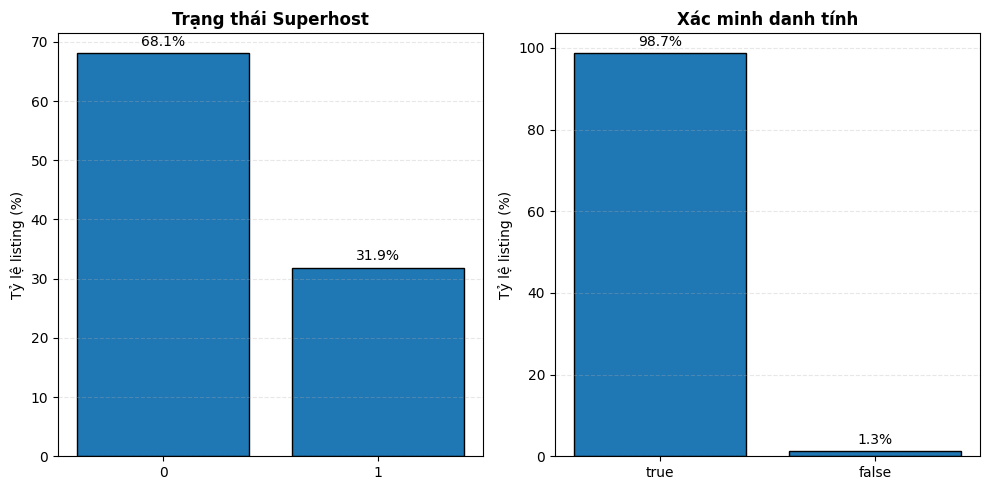

In [147]:
# Phân bố superhost và xác minh danh tính
binary_host_cols = [
    col for col in [
        "host_is_superhost",
        "host_identity_verified",
        "host_has_profile_pic"
    ]
    if col in listings_v2.columns
]

titles = {
    "host_is_superhost": "Trạng thái Superhost",
    "host_identity_verified": "Xác minh danh tính",
    "host_has_profile_pic": "Ảnh đại diện"
}

fig, axes = plt.subplots(
    1,
    len(binary_host_cols),
    figsize=(5 * len(binary_host_cols), 5)
)

if len(binary_host_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, binary_host_cols):
    shares = (
        listings_v2[col]
        .astype(str)
        .str.lower()
        .value_counts(normalize=True)
        .mul(100)
    )

    bars = ax.bar(
        shares.index,
        shares.values,
        edgecolor="black"
    )

    ax.set_title(titles[col], fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Tỷ lệ listing (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax.bar_label(bars, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

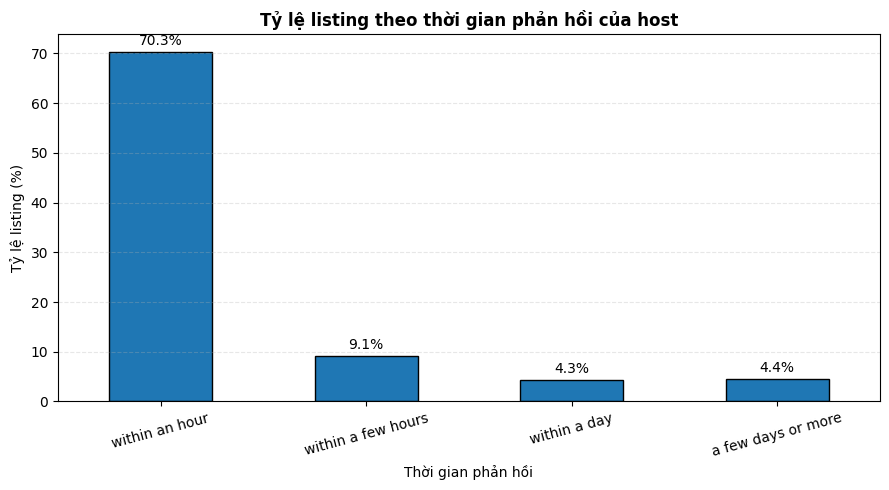

In [148]:
# Phân bố thời gian phản hồi
if "host_response_time" in listings_v2.columns:
    response_order = [
        "within an hour",
        "within a few hours",
        "within a day",
        "a few days or more"
    ]

    response_share = (
        listings_v2["host_response_time"]
        .value_counts(normalize=True)
        .reindex(response_order)
        .dropna()
        .mul(100)
    )

    ax = response_share.plot(
        kind="bar",
        figsize=(9, 5),
        edgecolor="black"
    )

    ax.set_title(
        "Tỷ lệ listing theo thời gian phản hồi của host",
        fontweight="bold"
    )
    ax.set_xlabel("Thời gian phản hồi")
    ax.set_ylabel("Tỷ lệ listing (%)")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

    plt.tight_layout()
    plt.show()

In [149]:
# Phân phối tỷ lệ phản hồi và chấp nhận
rate_cols = [
    col for col in [
        "host_response_rate",
        "host_acceptance_rate"
    ]
    if col in listings_v2.columns
]

for col in rate_cols:
    if listings_v2[col].dtype == "object":
        listings_v2[col] = pd.to_numeric(
            listings_v2[col]
            .str.replace("%", "", regex=False),
            errors="coerce"
        )

    if listings_v2[col].max() <= 1:
        listings_v2[col] = listings_v2[col] * 100

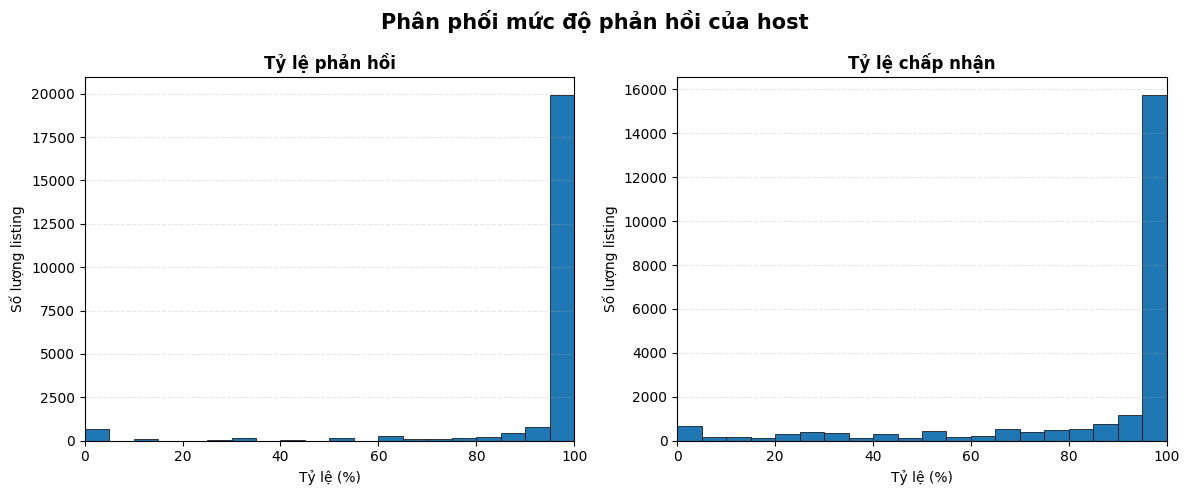

In [150]:
rate_titles = {
    "host_response_rate": "Tỷ lệ phản hồi",
    "host_acceptance_rate": "Tỷ lệ chấp nhận"
}

fig, axes = plt.subplots(
    1,
    len(rate_cols),
    figsize=(6 * len(rate_cols), 5)
)

if len(rate_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, rate_cols):
    ax.hist(
        listings_v2[col].dropna(),
        bins=20,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(rate_titles[col], fontweight="bold")
    ax.set_xlabel("Tỷ lệ (%)")
    ax.set_ylabel("Số lượng listing")
    ax.set_xlim(0, 100)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Phân phối mức độ phản hồi của host",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

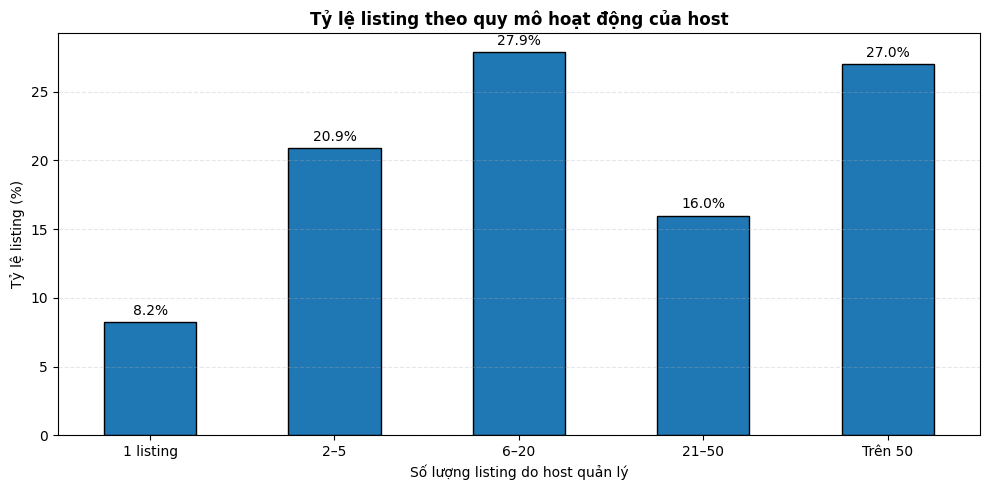

In [151]:
# Phân nhóm quy mô host
host_size_col = (
    "host_total_listings_count"
    if "host_total_listings_count" in listings_v2.columns
    else "host_listings_count"
)

host_size_labels = [
    "1 listing",
    "2–5",
    "6–20",
    "21–50",
    "Trên 50"
]

listings_v2["host_size_group"] = pd.cut(
    listings_v2[host_size_col],
    bins=[0, 1, 5, 20, 50, np.inf],
    labels=host_size_labels,
    include_lowest=True
)

host_size_share = (
    listings_v2["host_size_group"]
    .value_counts(normalize=True)
    .reindex(host_size_labels)
    .mul(100)
)

ax = host_size_share.plot(
    kind="bar",
    figsize=(10, 5),
    edgecolor="black"
)

ax.set_title(
    "Tỷ lệ listing theo quy mô hoạt động của host",
    fontweight="bold"
)
ax.set_xlabel("Số lượng listing do host quản lý")
ax.set_ylabel("Tỷ lệ listing (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [152]:
# Kinh nghiệm của host
if "host_since" in listings_v2.columns:
    listings_v2["host_since"] = pd.to_datetime(
        listings_v2["host_since"],
        errors="coerce"
    )

    reference_date = pd.Timestamp("2026-01-01")

    if "last_scraped" in listings_v2.columns:
        reference_date = pd.to_datetime(
            listings_v2["last_scraped"],
            errors="coerce"
        )

        listings_v2["host_years"] = (
            reference_date - listings_v2["host_since"]
        ).dt.days / 365.25

    else:
        listings_v2["host_years"] = (
            reference_date - listings_v2["host_since"]
        ).dt.days / 365.25

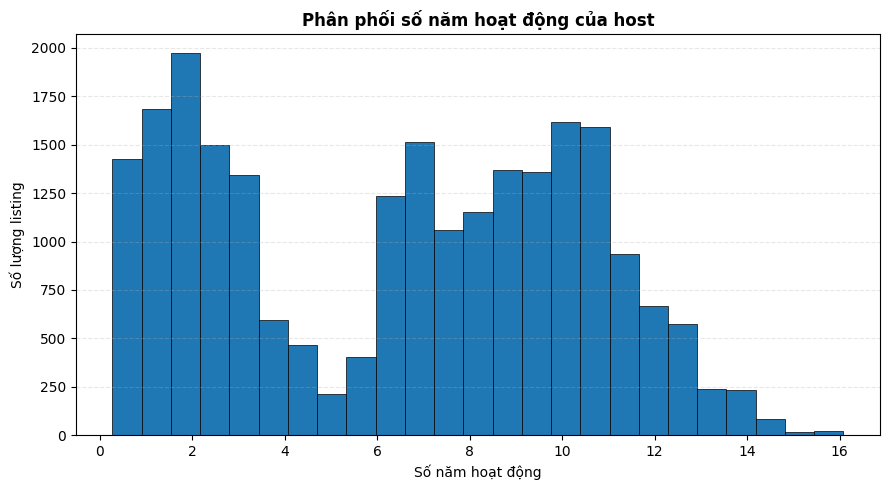

In [153]:
plt.figure(figsize=(9, 5))

plt.hist(
    listings_v2["host_years"].dropna(),
    bins=25,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Phân phối số năm hoạt động của host", fontweight="bold")
plt.xlabel("Số năm hoạt động")
plt.ylabel("Số lượng listing")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

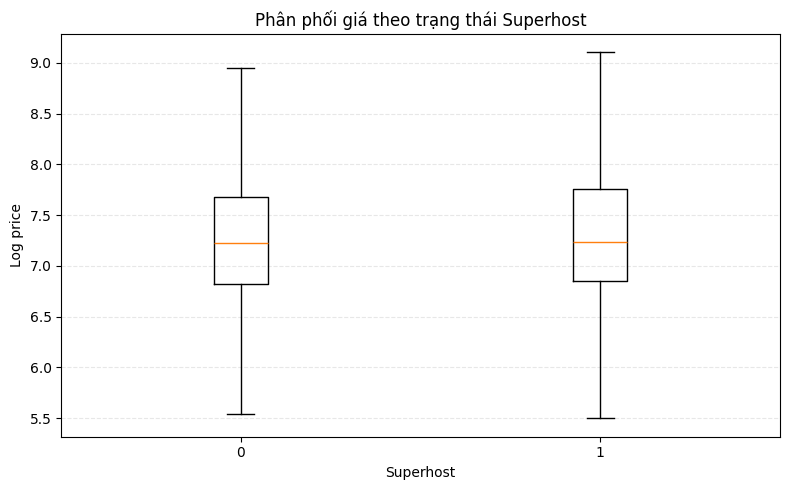

In [154]:
# Giá theo trạng thái superhost
if "host_is_superhost" in listings_v2.columns:
    superhost_groups = [
        group["log_price"].dropna().values
        for _, group in listings_v2.groupby(
            "host_is_superhost",
            observed=True
        )
    ]

    superhost_labels = [
        str(name)
        for name, _ in listings_v2.groupby(
            "host_is_superhost",
            observed=True
        )
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        superhost_groups,
        tick_labels=superhost_labels,
        showfliers=False
    )

    plt.title("Phân phối giá theo trạng thái Superhost")
    plt.xlabel("Superhost")
    plt.ylabel("Log price")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

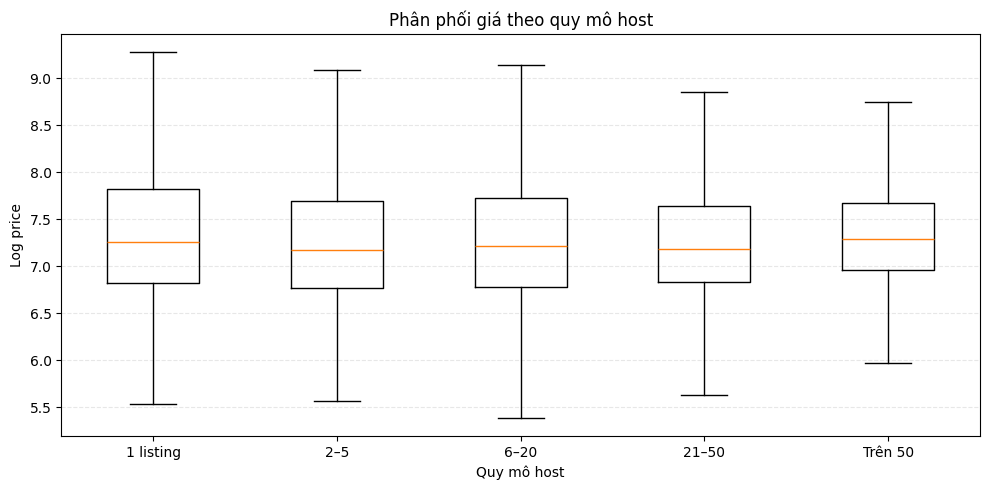

In [155]:
# Giá theo quy mô host
grouped_price = [
    listings_v2.loc[
        listings_v2["host_size_group"] == group,
        "log_price"
    ].dropna().values
    for group in host_size_labels
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    grouped_price,
    tick_labels=host_size_labels,
    showfliers=False
)

plt.title("Phân phối giá theo quy mô host")
plt.xlabel("Quy mô host")
plt.ylabel("Log price")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [156]:
# Tương quan giá
host_numeric_cols = [
    col for col in [
        "host_response_rate",
        "host_acceptance_rate",
        "host_listings_count",
        "host_total_listings_count",
        "host_years"
    ]
    if col in listings_v2.columns
]

host_price_corr = (
    listings_v2[host_numeric_cols + ["log_price"]]
    .corr(method="spearman")["log_price"]
    .drop("log_price")
    .sort_values()
    .round(3)
)

display(host_price_corr.to_frame("spearman_with_log_price"))

,spearman_with_log_price
host_years,-0.029
host_acceptance_rate,-0.013
host_response_rate,0.002
host_listings_count,0.049
host_total_listings_count,0.056


**Nhận xét:**
- 98.7% listing có host đã xác minh, biến gần như không còn khả năng phần biệt, nên giá trị dự báo thấp. 
- `host_response_rate` và `host_acceptance_rate` tập trung mạnh 100%, hiệu ứng trần nên khó phân biệt. 
- `log_price` của superhost và host thường gàn như tương đương.
- Nhóm quy mô host cũng có med gần nhau. 
- Tương quan các biến trong nhóm host thấp, không có quan hệ rõ ràng với mức giá. 